# Multi-Domain Document Classification System
### Domains: Finance · Medical · Technology · Sports

---

## Pipeline Overview

| Step | What happens | Why it matters |
|------|-------------|----------------|
| 1 | Load heterogeneous sources (CSV + Apple Numbers) | Single `text / label` dataframe |
| 2 | Preprocess — lowercase, regex clean, stopwords, length filter | Stable vocabulary across train & inference |
| 3 | Stratified 80/20 train-test **split before** balancing | Prevents oversampled duplicates leaking into test |
| 4 | Hybrid balance training set (cap + `RandomOverSampler`) | Stops Finance/Medical from drowning Sports/Tech |
| 5 | TF-IDF (1–2 grams) **+** manual keyword block | Learned weights + curated priors work together |
| 6 | `MultinomialNB` with `GridSearchCV` on `alpha` | Fast, calibrated, sparse-friendly |
| 7 | Evaluate + confusion matrix + baseline comparison | Identify weak classes |
| 8 | Save `model.pkl` + `vectorizer.pkl` | Ready for API / Streamlit |
| 9 | Live predictions with confidence + keyword ranking | End-to-end demonstration |

---

> **Legal domain** is reserved — add it in `config.py` + `domain_keywords.py` + `dataset_loader.py` and retrain.

## Cell 1 — Imports & Environment Setup

In [1]:
import json
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Resolve project root whether notebook is opened from /notebooks or project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

from mdcs.balance import hybrid_balance
from mdcs.config import BALANCE_MAX_PER_CLASS, DOMAINS, MODELS_DIR, RANDOM_STATE
from mdcs.dataset_loader import build_master_dataframe
from mdcs.features import build_tfidf_vectorizer, hstack_tfidf_keywords, keyword_match_matrix
from mdcs.predictor import DomainClassifier, predict_domain
from mdcs.preprocess import preprocess_pipeline

print(f"Project root : {ROOT}")
print(f"Active domains: {DOMAINS}")
print(f"Models dir    : {MODELS_DIR}")

Matplotlib is building the font cache; this may take a moment.


Project root : /Users/prachigoyal/multi_domain_doc_classifier
Active domains: ('Finance', 'Medical', 'Sports', 'Technology')
Models dir    : /Users/prachigoyal/multi_domain_doc_classifier/models


## Cell 2 — Dataset Loading & Analysis

Sources used:

| File | Label | Notes |
|------|-------|-------|
| `Financial.csv` | Finance | Title + Tag + Content combined |
| `train.csv` | Medical | PubMed abstracts — lines grouped by `abstract_id` |
| `tech.numbers` | Technology | Apple Numbers — 230 BBC tech articles |
| `sports.numbers` | Sports | Apple Numbers — 457 BBC sports articles |

In [2]:
master, reports = build_master_dataframe()

print("=== Raw dataset statistics ===")
for r in reports:
    print(f"\n[{r['name']}]")
    print(f"  rows          : {r['rows']}")
    print(f"  missing text  : {r['missing_text']}")
    print(f"  duplicates    : {r['dup_text']}")
    print(f"  short docs    : {r['short_docs']}")
    print(f"  label counts  : {r['label_counts']}")

print("\n=== Combined master shape ===")
print(f"  Total rows : {len(master)}")
print(f"  Label dist :\n{master['label'].value_counts().to_string()}")

=== Raw dataset statistics ===

[finance]
  rows          : 15000
  missing text  : 0
  duplicates    : 0
  short docs    : 0
  label counts  : {'Finance': 15000}

[medical_aggregated]
  rows          : 12000
  missing text  : 0
  duplicates    : 0
  short docs    : 0
  label counts  : {'Medical': 12000}

[technology_numbers]
  rows          : 203
  missing text  : 0
  duplicates    : 0
  short docs    : 0
  label counts  : {'Technology': 203}

[sports_numbers]
  rows          : 443
  missing text  : 0
  duplicates    : 0
  short docs    : 0
  label counts  : {'Sports': 443}

=== Combined master shape ===
  Total rows : 27646
  Label dist :
label
Finance       15000
Medical       12000
Sports          443
Technology      203


## Cell 3 — Text Preprocessing

**Why preprocessing matters:**
- Lowercase + punctuation removal → TF-IDF sees `market` not `Market`, `Market.` as separate tokens
- Stopword removal → avoids common words (`the`, `is`) wasting feature budget
- Length filter → removes broken / empty rows that add noise

The same function is called at inference time so train/test vocabularies stay aligned.

In [3]:
def preprocess_frame(df):
    texts_raw = df["text"].astype(str).tolist()
    cleaned, kept_idx = [], []
    for i, t in enumerate(texts_raw):
        c = preprocess_pipeline(t, min_chars=40)
        if c:
            cleaned.append(c)
            kept_idx.append(i)
    sub = df.iloc[kept_idx].reset_index(drop=True)
    sub["text_clean"] = cleaned
    sub["text_raw"] = sub["text"].astype(str)
    return sub

prep = preprocess_frame(master)

# Show a before/after example
sample_idx = 0
print("BEFORE:", master.iloc[sample_idx]["text"][:200])
print("\nAFTER :", prep.iloc[sample_idx]["text_clean"][:200])
print(f"\nRows kept after filtering: {len(prep)} / {len(master)}")

BEFORE: DXY Erases Gains Currency DXY Erases GainsUnited States CurrencyThe dollar index fell more than 0.5% to below 105 from an 20-year high of 105.8 hit earlier in the session as risk sentiment returned to

AFTER : dxy erases gains currency dxy erases gainsunited states currencythe dollar index fell 105 20 year high 105 hit earlier session risk sentiment returned markets became clear fed fully committed fighting

Rows kept after filtering: 27640 / 27646


## Cell 4 — Train/Test Split (BEFORE Balancing)

**Why split first?**  
`RandomOverSampler` creates bootstrap duplicates of minority rows. If you balance _then_ split, those duplicates can end up in both train and test — inflating accuracy artificially. Splitting first guarantees the test set contains only original, unseen documents.

In [4]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    prep,
    prep["label"],
    test_size=0.2,
    stratify=prep["label"],
    random_state=RANDOM_STATE,
)

print("Train label counts:")
print(X_train_df["label"].value_counts().to_string())
print("\nTest label counts:")
print(X_test_df["label"].value_counts().to_string())

Train label counts:
label
Finance       12000
Medical        9600
Sports          353
Technology      159

Test label counts:
label
Finance       3000
Medical       2400
Sports          88
Technology      40


## Cell 5 — Dataset Balancing

**Strategy: Hybrid (undersample cap → oversample)**

1. **Undersampling** — cap any class above `max_per_class` to avoid Medical/Finance monopolising TF-IDF vocabulary.
2. **Oversampling** — `RandomOverSampler` brings every class up to the same target by bootstrapping minority rows.

Pure undersampling would throw away real Finance/Medical signal. Pure oversampling with massive imbalance (1 tech doc vs 12000 medical docs) still leaves priors skewed. Hybrid is the best of both.

Balancing method : undersample_cap_then_random_oversample
Rationale        : Finance/Medical dominate raw counts; Tech/Sports are tiny. Capping majority limits duplicated mass-market n-grams; oversampling minorities prevents NB class priors from washing out Technology/Sports signals.

Before (raw)     : {'Finance': 12000, 'Medical': 9600, 'Sports': 353, 'Technology': 159}
After cap        : {'Finance': 8000, 'Medical': 8000, 'Sports': 353, 'Technology': 159}
After oversample : {'Finance': 8000, 'Medical': 8000, 'Sports': 8000, 'Technology': 8000}


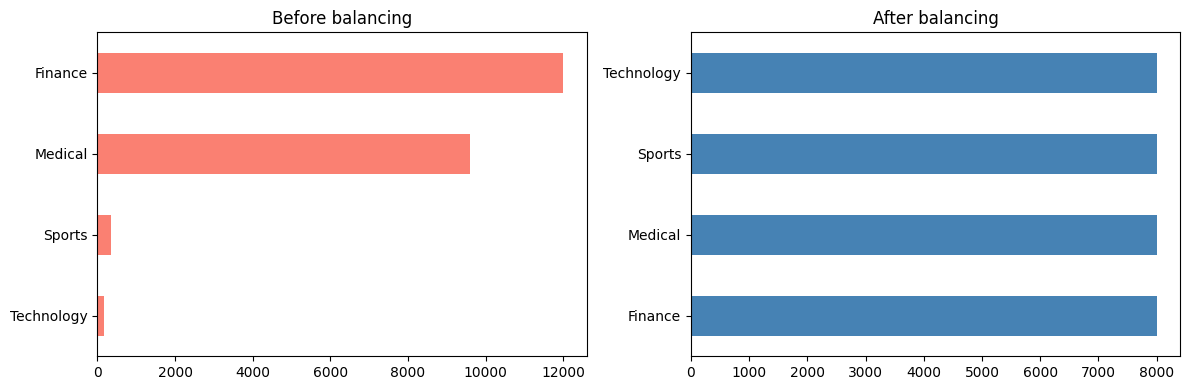

In [5]:
X_train_bal, bal_meta = hybrid_balance(
    X_train_df.reset_index(drop=True),
    max_per_class=BALANCE_MAX_PER_CLASS,
    random_state=RANDOM_STATE,
)

print("Balancing method :", bal_meta["method"])
print("Rationale        :", bal_meta["rationale"])
print("\nBefore (raw)     :", bal_meta["before_counts"])
print("After cap        :", bal_meta["after_cap_counts"])
print("After oversample :", bal_meta["final_counts"])

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(bal_meta["before_counts"]).sort_values().plot.barh(ax=axes[0], color="salmon", title="Before balancing")
pd.Series(bal_meta["final_counts"]).sort_values().plot.barh(ax=axes[1], color="steelblue", title="After balancing")
plt.tight_layout()
plt.show()

## Cell 6 — Feature Engineering: TF-IDF + Manual Keywords

**TF-IDF (Term Frequency–Inverse Document Frequency)**  
- Rewards terms that appear often in a document but rarely across all documents → discriminative features.  
- `sublinear_tf=True` compresses extreme term counts with log.  
- 1–2 grams capture phrases like `interest rate`, `blood pressure`, `neural network`.

**Manual keyword block**  
- Four extra features (one per domain) — normalised hit scores from ~50 curated keywords per domain.  
- Scaled up so they can compete against tens of thousands of TF-IDF dimensions.  
- Closes vocabulary gaps (e.g. `venture capital`, `genai`) that may not appear in training data.

In [6]:
vec = build_tfidf_vectorizer(ngram_max=2, max_features=55_000, min_df=2, max_df=0.92)

Xtr = hstack_tfidf_keywords(
    vec.fit_transform(X_train_bal["text_clean"]),
    keyword_match_matrix(X_train_bal["text_raw"], list(DOMAINS)),
)
Xte = hstack_tfidf_keywords(
    vec.transform(X_test_df["text_clean"]),
    keyword_match_matrix(X_test_df["text_raw"], list(DOMAINS)),
)

y_tr = np.asarray(X_train_bal["label"].tolist())
y_te = np.asarray(y_test.tolist())

print(f"Train feature matrix : {Xtr.shape}  (TF-IDF + 4 keyword dims)")
print(f"Test  feature matrix : {Xte.shape}")
print(f"Vocabulary size      : {len(vec.vocabulary_)}")

Train feature matrix : (32000, 55004)  (TF-IDF + 4 keyword dims)
Test  feature matrix : (5528, 55004)
Vocabulary size      : 55000


## Cell 7 — Model Training: Multinomial Naive Bayes

**Why Naive Bayes?**
- Works extremely well with sparse TF-IDF features (bag-of-words matches the independence assumption).
- Fast to train even on tens of thousands of features.
- Returns calibrated `predict_proba` — needed for the confidence + ranking system.
- `alpha` (Laplace smoothing) prevents zero-probability on unseen tokens; tuned via `GridSearchCV`.

In [7]:
grid = GridSearchCV(
    MultinomialNB(),
    param_grid={"alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]},
    scoring="f1_macro",
    cv=4,
    n_jobs=1,
)
grid.fit(Xtr, y_tr)
model = grid.best_estimator_

print(f"Best alpha    : {grid.best_params_['alpha']}")
print(f"CV f1_macro   : {grid.best_score_:.4f}")
print(f"Classes order : {model.classes_}  ← must match DOMAINS order")

Best alpha    : 0.01
CV f1_macro   : 0.9879
Classes order : ['Finance' 'Medical' 'Sports' 'Technology']  ← must match DOMAINS order


## Cell 8 — Evaluation on Held-Out Test Set

In [8]:
y_pred = model.predict(Xte)

acc = accuracy_score(y_te, y_pred)
f1  = f1_score(y_te, y_pred, average="macro")

print(f"Holdout Accuracy : {acc:.4f}")
print(f"Macro F1-Score   : {f1:.4f}")
print()
print(classification_report(y_te, y_pred, digits=3))

Holdout Accuracy : 0.9964
Macro F1-Score   : 0.9705

              precision    recall  f1-score   support

     Finance      0.998     0.997     0.997      3000
     Medical      0.997     0.998     0.998      2400
      Sports      0.956     0.977     0.966        88
  Technology      0.972     0.875     0.921        40

    accuracy                          0.996      5528
   macro avg      0.981     0.962     0.971      5528
weighted avg      0.996     0.996     0.996      5528



### Confusion Matrix

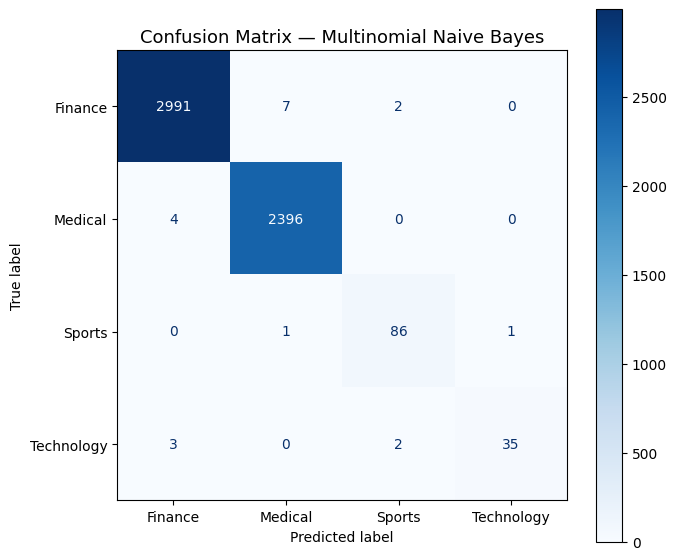


Raw confusion matrix (rows=true, cols=predicted):
[[2991    7    2    0]
 [   4 2396    0    0]
 [   0    1   86    1]
 [   3    0    2   35]]


In [9]:
cm = confusion_matrix(y_te, y_pred, labels=list(DOMAINS))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(DOMAINS))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Multinomial Naive Bayes", fontsize=13)
plt.tight_layout()
plt.show()

print("\nRaw confusion matrix (rows=true, cols=predicted):")
print(cm)

## Cell 9 — Optional Baseline Comparison (LR / LinearSVC / RF)

These use the same TF-IDF + keyword features but a subsampled training set for speed. The final deployed model remains MultinomialNB.

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(Xtr.shape[0], size=min(8_000, Xtr.shape[0]), replace=False)
Xs, ys = Xtr[idx], y_tr[idx]

results = {}

lr = LogisticRegression(max_iter=300, random_state=RANDOM_STATE)
lr.fit(Xs, ys)
results["Logistic Regression"] = round(f1_score(y_te, lr.predict(Xte), average="macro"), 4)

svm = LinearSVC()
svm.fit(Xs, ys)
results["LinearSVC"] = round(accuracy_score(y_te, svm.predict(Xte)), 4)

rf = RandomForestClassifier(n_estimators=80, max_depth=24, random_state=RANDOM_STATE, n_jobs=1)
rf.fit(Xs, ys)
results["Random Forest"] = round(f1_score(y_te, rf.predict(Xte), average="macro"), 4)

results["MultinomialNB (final)"] = round(f1, 4)

print("Model comparison (f1_macro or accuracy on 8k subsample):")
for name, score in results.items():
    bar = "█" * int(score * 40)
    print(f"  {name:<30} {score:.4f}  {bar}")

Model comparison (f1_macro or accuracy on 8k subsample):
  Logistic Regression            0.8484  █████████████████████████████████
  LinearSVC                      0.9995  ███████████████████████████████████████
  Random Forest                  0.9546  ██████████████████████████████████████
  MultinomialNB (final)          0.9705  ██████████████████████████████████████


## Cell 10 — Save Model Artifacts

In [11]:
clf = DomainClassifier(vec, model, domains=None)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
clf.save(MODELS_DIR)

print(f"model.pkl      saved → {MODELS_DIR / 'model.pkl'}")
print(f"vectorizer.pkl saved → {MODELS_DIR / 'vectorizer.pkl'}")
print(f"Domains in saved model: {clf.domains}")

model.pkl      saved → /Users/prachigoyal/multi_domain_doc_classifier/models/model.pkl
vectorizer.pkl saved → /Users/prachigoyal/multi_domain_doc_classifier/models/vectorizer.pkl
Domains in saved model: [np.str_('Finance'), np.str_('Medical'), np.str_('Sports'), np.str_('Technology')]


## Cell 11 — Live Prediction Demo

For each sample text the system returns:
- **Predicted domain**
- **Confidence %** from `predict_proba`
- **Ranked probabilities** for all 4 domains
- **Top TF-IDF terms** that drove the decision
- **Matched manual keywords** from curated lexicon

In [12]:
test_samples = [
    (
        "FINANCE",
        "The Federal Reserve raised interest rates by 25 basis points as inflation "
        "continues to persist. Stock markets fell with NASDAQ down 1.2%. Bitcoin dropped "
        "below 30000. Treasury bond yields rose to 4.5%.",
    ),
    (
        "MEDICAL",
        "The patient was diagnosed with stage 2 breast cancer. MRI scan confirmed the tumor. "
        "The oncologist recommended chemotherapy followed by surgical removal. Blood pressure "
        "and immunity levels were monitored throughout treatment.",
    ),
    (
        "TECHNOLOGY",
        "OpenAI released a new large language model with improved NLP capabilities. Engineers "
        "deployed it on cloud infrastructure using Docker and Kubernetes. The model runs on "
        "GPU clusters with PyTorch and TensorFlow backends.",
    ),
    (
        "SPORTS",
        "India won the cricket world cup final against Australia. Virat Kohli scored a "
        "brilliant century with a strike rate of 145. The stadium was packed with 80,000 "
        "fans as the captain lifted the trophy.",
    ),
]

print("=" * 72)
for expected, text in test_samples:
    r = predict_domain(text)
    predicted = r["predicted_domain"]
    match = "✓ CORRECT" if predicted.upper() == expected else "✗ WRONG"
    ranked = sorted(r["probabilities_percent"].items(), key=lambda x: -x[1])
    matched_kws = {k: v for k, v in r["matched_manual_keywords"].items() if v}

    print(f"\n{match}")
    print(f"  Expected  : {expected}")
    print(f"  Predicted : {predicted}  ({r['confidence_percent']}% confidence)")
    print(f"  All ranks : {ranked}")
    print(f"  Top terms : {[t[0] for t in r['top_tfidf_terms'][:6]]}")
    print(f"  Keywords  : {matched_kws}")
    print("-" * 72)


✓ CORRECT
  Expected  : FINANCE
  Predicted : Finance  (100.0% confidence)
  All ranks : [('Finance', 100.0), ('Medical', 0.0), ('Sports', 0.0), ('Technology', 0.0)]
  Top terms : ['reserve raised', 'bitcoin', 'treasury bond', 'raised interest', 'rates 25', 'fell nasdaq']
  Keywords  : {'Finance': ['stock', 'market', 'inflation', 'bond', 'interest rate', 'bitcoin', 'nasdaq']}
------------------------------------------------------------------------

✓ CORRECT
  Expected  : MEDICAL
  Predicted : Medical  (100.0% confidence)
  All ranks : [('Medical', 100.0), ('Finance', 0.0), ('Sports', 0.0), ('Technology', 0.0)]
  Top terms : ['stage breast', 'throughout treatment', 'monitored throughout', 'mri scan', 'immunity', 'mri']
  Keywords  : {'Medical': ['patient', 'treatment', 'therapy', 'cancer', 'blood pressure', 'mri', 'immunity', 'surgical']}
------------------------------------------------------------------------

✓ CORRECT
  Expected  : TECHNOLOGY
  Predicted : Technology  (100.0% confi

## Cell 12 — Predict Your Own Text

Paste any text in the variable below and run the cell.

In [13]:
my_text = """
Paste or type your document text here.
"""

r = predict_domain(my_text)

print(f"Predicted Domain : {r['predicted_domain']}")
print(f"Confidence       : {r['confidence_percent']}%")
print()
print("Domain Probability Ranking:")
for domain, prob in sorted(r['probabilities_percent'].items(), key=lambda x: -x[1]):
    bar = "█" * int(prob / 2.5)
    print(f"  {domain:<12} {prob:>6.2f}%  {bar}")
print()
print("Top TF-IDF terms :", [t[0] for t in r['top_tfidf_terms'][:10]])
print("Matched keywords :", {k: v for k, v in r['matched_manual_keywords'].items() if v})

Predicted Domain : Medical
Confidence       : 99.88%

Domain Probability Ranking:
  Medical       99.88%  ███████████████████████████████████████
  Finance        0.11%  
  Technology     0.01%  
  Sports         0.00%  

Top TF-IDF terms : ['paste', 'document', 'text', 'type']
Matched keywords : {}


## Cell 13 — Predict a PDF / DOCX / TXT File

In [28]:
from mdcs.predictor import predict_document

# Change this path to your file
FILE_PATH = "/Users/prachigoyal/Desktop/tech.pdf"  # .pdf  .docx  .txt

if Path(FILE_PATH).exists():
    r = predict_document(FILE_PATH)
    print(f"File             : {FILE_PATH}")
    print(f"Predicted Domain : {r['predicted_domain']}")
    print(f"Confidence       : {r['confidence_percent']}%")
    print()
    print("Domain Probability Ranking:")
    for domain, prob in sorted(r['probabilities_percent'].items(), key=lambda x: -x[1]):
        bar = "█" * int(prob / 2.5)
        print(f"  {domain:<12} {prob:>6.2f}%  {bar}")
    print()
    print("Top TF-IDF terms :", [t[0] for t in r['top_tfidf_terms'][:10]])
    print("Matched keywords :", {k: v for k, v in r['matched_manual_keywords'].items() if v})
else:
    print(f"File not found: {FILE_PATH}")
    print("Update FILE_PATH above and re-run this cell.")

File             : /Users/prachigoyal/Desktop/tech.pdf
Predicted Domain : Medical
Confidence       : 99.68%

Domain Probability Ranking:
  Medical       99.68%  ███████████████████████████████████████
  Technology     0.32%  
  Finance        0.00%  
  Sports         0.00%  

Top TF-IDF terms : ['intelligence', 'organizations', 'systems', 'artificial', 'computing', 'modern', 'frameworks', 'engineering', 'smart', 'autonomous']
Matched keywords : {'Finance': ['market', 'currency', 'analytics', 'liability', 'cryptocurrency'], 'Medical': ['healthcare', 'health'], 'Sports': ['fitness'], 'Technology': ['artificial intelligence', 'machine learning', 'deep learning', 'neural network', 'data science', 'software', 'hardware', 'algorithm', 'cloud computing', 'cybersecurity', 'database', 'api', 'automation', 'robotics', 'blockchain', 'iot', 'internet', 'server', 'frontend', 'backend', 'full stack', 'devops', 'computer vision', 'big data', 'analytics']}
